In [1]:
import json
import plotly.express as px
import pandas as pd
import openpyxl
import pandas as pd
import matplotlib.pyplot as plt

## Tender schedule with starting point

In [2]:
with open('Deterministic_results_with_start.json') as json_file:
    F_results = json.load(json_file)


In [3]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["F"]

# Initialize a dictionary to store grouped results
grouped_results = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results[keyword].append({key: value})

# Print the grouped results
# for keyword, results in grouped_results.items():
#     print(f'Keyword: {keyword}')
#     for result in results:
#         print(f'  {result}')
#     print()


In [4]:
# create dictionary from F data from above
# Extracting information from the dictionary
data_list = []
for item in grouped_results['F']:
    key, value = list(item.items())[0]
    # print(key)
    tender = key.split('[', 1)[1].split(',', 1)[0]
    start, finish = eval(key.split('(', 1)[1].split(')', 1)[0])
    value = item[key]
    
    data_list.append({'Tender': tender, 'Start': start, 'Finish': finish, 'Value': value})

# Create a DataFrame
F_values_df = pd.DataFrame(data_list)

# Display the DataFrame
F_values_df.head()


,Tender,Start,Finish,Value
0,Hepatitis_B,3,7,-0.0
1,Hepatitis_B,5,5,-0.0
2,Mumps,1,1,0.0
3,Polio,2,4,0.0
4,Tetanus,3,3,-0.0


In [5]:
#check to make sure all tenders are accounted for in model results
def lists_contain_same_strings(list1, list2):
    return set(list1) == set(list2)

# Example usage
list_a = list(F_values_df.Tender.unique())
list_b = ["Measles","Mumps","Rubella","Diphtheria","Tetanus","Pertussis",
          "Hepatitis_B","Hib","Polio","HPV","Rotavirus","PCV"]

lists_contain_same_strings(list_a, list_b)


True

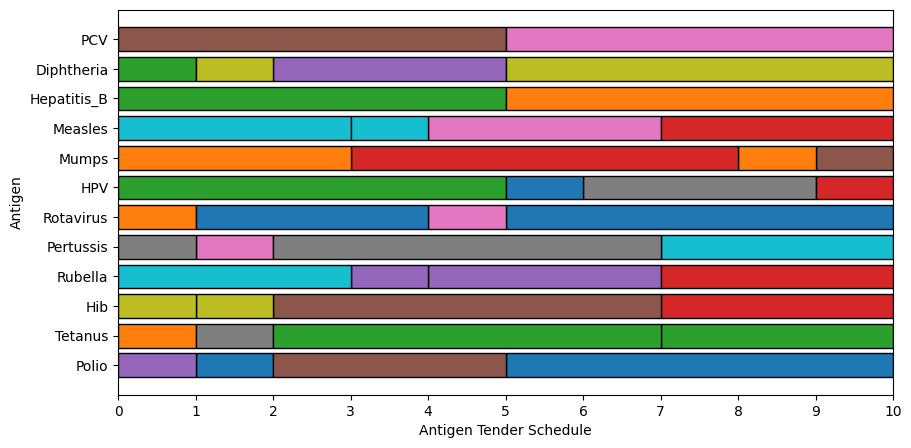

In [8]:
# plot the F (tenders) schedule to visualize results
# Create a new figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Iterate through rows and plot bars based on conditions
for index, row in F_values_df.iterrows():
    if row['Value'] == 1:
        start = row['Start']-1
        end = row['Finish'] 
        ax.barh(row['Tender'], width=end - start, left=start, edgecolor='black')

# Set labels and show the plot
ax.set_xlim(0, 10)
ax.set_xticks(range(11))

ax.set_xlabel('Antigen Tender Schedule')
ax.set_ylabel('Antigen')
plt.title('Determistic Tender Schedule - With Start Point')
plt.savefig('Deterministic_Tenders_With_Start.png')
plt.show()


## Tender Schedule without starting point

In [17]:
with open('Deterministic_results.json') as json_file:
    F_results_clean = json.load(json_file)

In [18]:
# Search results by keyword for F (tender schedules)
# List of keywords to search for
keywords_to_search = ["F"]

# Initialize a dictionary to store grouped results
grouped_results_clean = {keyword: [] for keyword in keywords_to_search}

# Search for keywords in the JSON keys and group the results
for key, value in F_results_clean.items():
    for keyword in keywords_to_search:
        if keyword in key:
            grouped_results_clean[keyword].append({key: value})

# Print the grouped results
# for keyword, results in grouped_results_clean.items():
#     print(f'Keyword: {keyword}')
#     for result in results:
#         print(f'  {result}')
#     print()


In [21]:
# create dictionary from F data from above
# Extracting information from the dictionary
data_list = []
for item in grouped_results_clean['F']:
    key, value = list(item.items())[0]
    # print(key)
    tender = key.split('[', 1)[1].split(',', 1)[0]
    start, finish = eval(key.split('(', 1)[1].split(')', 1)[0])
    value = item[key]
    
    data_list.append({'Tender': tender, 'Start': start, 'Finish': finish, 'Value': value})

# Create a DataFrame
F_values_clean_df = pd.DataFrame(data_list)

# Display the DataFrame
F_values_clean_df.head()


,Tender,Start,Finish,Value
0,Diphtheria,7,9,-0.0
1,Mumps,7,7,-0.0
2,Hepatitis_B,6,6,-0.0
3,Tetanus,7,7,-0.0
4,HPV,2,6,-0.0


In [22]:
#check to make sure all tenders are accounted for in model results
def lists_contain_same_strings(list1, list2):
    return set(list1) == set(list2)

# Example usage
list_a = list(F_values_clean_df.Tender.unique())
list_b = ["Measles","Mumps","Rubella","Diphtheria","Tetanus","Pertussis",
          "Hepatitis_B","Hib","Polio","HPV","Rotavirus","PCV"]

lists_contain_same_strings(list_a, list_b)


True

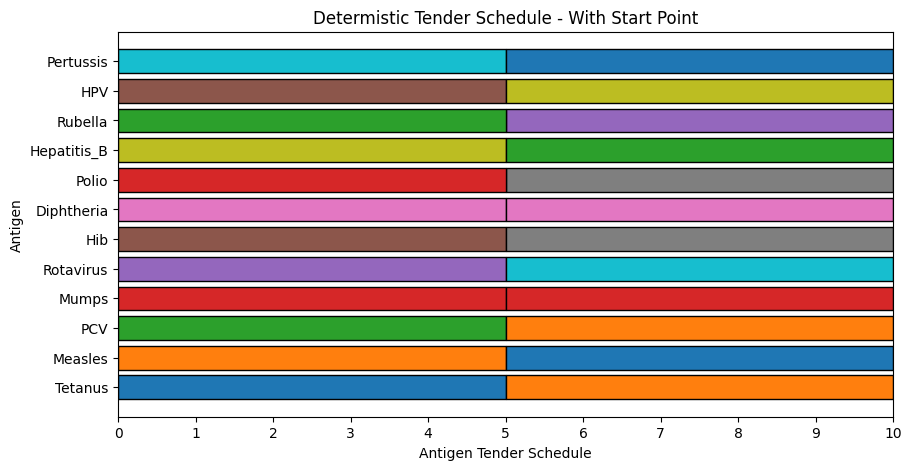

In [23]:
# plot the F (tenders) schedule to visualize results
# Create a new figure and axis
fig, ax = plt.subplots(figsize=(10, 5))

# Iterate through rows and plot bars based on conditions
for index, row in F_values_clean_df.iterrows():
    if row['Value'] == 1:
        start = row['Start']-1
        end = row['Finish'] 
        ax.barh(row['Tender'], width=end - start, left=start, edgecolor='black')

# Set labels and show the plot
ax.set_xlim(0, 10)
ax.set_xticks(range(11))

ax.set_xlabel('Antigen Tender Schedule')
ax.set_ylabel('Antigen')
plt.title('Determistic Tender Schedule - With Start Point')
plt.savefig('Deterministic_Tenders_With_Start.png')
plt.show()
